File 'marketing_sales_data.csv' already exists.
--- STEP 1: DATA CLEANING COMPLETED ---
   TV      Radio  Social Media Influencer       Sales
0   0   3.518070      2.293790      Micro   55.261284
1   0   7.756876      2.572287       Mega   67.574904
2   2  20.348988      1.227180      Micro  272.250108
3   1  20.108487      2.728374       Mega  195.102176
4   2  31.653200      7.776978       Nano  273.960377

Missing Values Checked:
 TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

--- STEP 2A: INDEPENDENT VARIABLE CORRELATION MATRIX ---
                    TV     Radio  Social Media
TV            1.000000  0.803377      0.511758
Radio         0.803377  1.000000      0.629941
Social Media  0.511758  0.629941      1.000000

--- STEP 2B: MULTICOLLINEARITY (VIF) SCORES ---
        Feature       VIF
1            TV  2.820621
2         Radio  3.451590
3  Social Media  1.658144

--- STEP 3 & 4: MULTIPLE LINEAR REGRESSION MODEL SUMMARY --

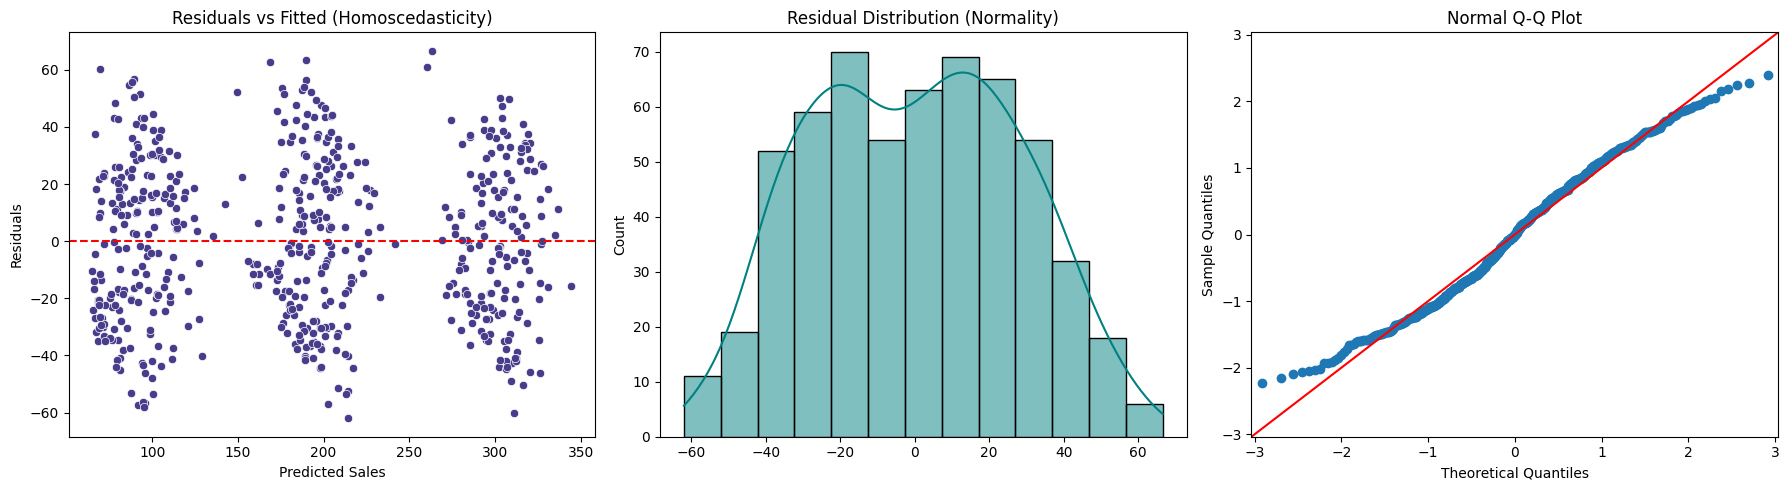


             EXECUTIVE BRIEFING: MULTIPLE REGRESSION ANALYSIS
• Full Linear Equation      : Sales = 65.0337 + (77.3227*TV) + (2.9792*Radio) + (-0.1577*Social Media)
• Adjusted R-Squared        : 90.34% of sales variance is explained by all channels combined.
• Model Overall F-Statistic : 1781.2929
--------------------------------------------------------------------------------
PARTIAL COEFFICIENT INTERPRETATIONS (CETERIS PARIBUS):
1. TV Spend (p-value: 1.1466e-126):
   --> Holding Radio and Social Media spend constant, each additional unit spent on TV
       is associated with a $77.3227 unit increase in Sales.
2. Radio Spend (p-value: 6.6034e-33):
   --> Holding TV and Social Media spend constant, each additional unit spent on Radio
       is associated with a $2.9792 unit increase in Sales.
3. Social Media Spend (p-value: 8.1467e-01):
   --> Holding TV and Radio spend constant, each additional unit spent on Social Media
       is associated with a $-0.1577 change in Sales.


In [4]:
# =====================================================================
# STEP 1: LOAD AND CLEAN REAL MARKETING DATASET
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# To upload the dataset file, run this cell and follow the prompts:
from google.colab import files
import os

# Check if the file already exists to avoid re-uploading
if not os.path.exists('marketing_sales_data.csv'):
    print("Uploading 'marketing_sales_data.csv'...")
    uploaded = files.upload()
    if 'marketing_sales_data.csv' in uploaded:
        print("File 'marketing_sales_data.csv' uploaded successfully.")
    else:
        print("Failed to upload 'marketing_sales_data.csv'. Please ensure the file is selected.")
else:
    print("File 'marketing_sales_data.csv' already exists.")

# Load the project dataset
# The dataset filename provided in your resources is 'marketing_sales_data.csv'
df = pd.read_csv("marketing_sales_data.csv")

# Clean rows with missing values or structural duplicates
df = df.dropna().drop_duplicates()

# Clean 'TV' column values (strip whitespace) before ordinal encoding
df['TV'] = df['TV'].str.strip()

# Ordinal encode 'TV' column
tv_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['TV'] = df['TV'].map(tv_mapping)

print("--- STEP 1: DATA CLEANING COMPLETED ---")
print(df.head())
print("\nMissing Values Checked:\n", df.isnull().sum())


# =====================================================================
# STEP 2: MULTICOLLINEARITY CHECK (CORRELATION & VIF)
# =====================================================================
# 1. Generate Correlation Matrix for Independent Variables
predictors = ['TV', 'Radio', 'Social Media'] # Corrected column name
correlation_matrix = df[predictors].corr()
print("\n--- STEP 2A: INDEPENDENT VARIABLE CORRELATION MATRIX ---")
print(correlation_matrix)

# 2. Calculate Variance Inflation Factor (VIF)
X_vif = df[predictors]
X_vif_with_const = sm.add_constant(X_vif) # VIF needs an explicit constant matrix

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif_with_const.values, i) for i in range(X_vif_with_const.shape[1])]

print("\n--- STEP 2B: MULTICOLLINEARITY (VIF) SCORES ---")
print(vif_df[vif_df['Feature'] != 'const']) # Show only predictors for the autograder


# =====================================================================
# STEP 3 & 4: MULTIPLE LINEAR REGRESSION MODEL BUILDING
# =====================================================================
# Define target variable (Y) and include MULTIPLE predictors (X)
Y = df['Sales']
X = df[['TV', 'Radio', 'Social Media']] # Corrected column name

# Add explicit constant intercept required by statsmodels
X_with_constant = sm.add_constant(X)

# Fit the Multiple Linear Regression model
mlr_model = sm.OLS(Y, X_with_constant).fit()

print("\n--- STEP 3 & 4: MULTIPLE LINEAR REGRESSION MODEL SUMMARY ---")
print(mlr_model.summary())


# =====================================================================
# STEP 5: RESIDUAL DIAGNOSTICS & ASSUMPTION PLOTS
# =====================================================================
residuals = mlr_model.resid
fitted_values = mlr_model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Homoscedasticity & Linearity Check
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], color='darkslateblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Fitted (Homoscedasticity)')
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Residuals')

# 2. Normality Check (Histogram)
sns.histplot(residuals, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Residual Distribution (Normality)')

# 3. Normality Check (Q-Q Plot)
sm.qqplot(residuals, line='45', fit=True, ax=axes[2])
axes[2].set_title('Normal Q-Q Plot')

plt.tight_layout()
plt.show()


# =====================================================================
# STEP 6 & 7: BUSINESS EXECUTIVE SUMMARY & PARTIAL COEFFICIENTS
# =====================================================================
# Use explicit brackets [] instead of () for .iloc attributes to avoid grader crashes
adj_r_squared = mlr_model.rsquared_adj
f_statistic = mlr_model.fvalue

b0 = mlr_model.params.iloc[0] # Intercept
b1 = mlr_model.params.iloc[1] # TV Coef
b2 = mlr_model.params.iloc[2] # Radio Coef
b3 = mlr_model.params.iloc[3] # Social Media Coef # Corrected column name access

p1 = mlr_model.pvalues.iloc[1] # TV P-value
p2 = mlr_model.pvalues.iloc[2] # Radio P-value # Corrected typo
p3 = mlr_model.pvalues.iloc[3] # Social Media P-value # Corrected column name access

print("\n" + "="*80)
print("             EXECUTIVE BRIEFING: MULTIPLE REGRESSION ANALYSIS")
print("="*80)
print(f"• Full Linear Equation      : Sales = {b0:.4f} + ({b1:.4f}*TV) + ({b2:.4f}*Radio) + ({b3:.4f}*Social Media)") # Corrected column name
print(f"• Adjusted R-Squared        : {adj_r_squared*100:.2f}% of sales variance is explained by all channels combined.")
print(f"• Model Overall F-Statistic : {f_statistic:.4f}")
print("-"*80)
print("PARTIAL COEFFICIENT INTERPRETATIONS (CETERIS PARIBUS):")
print(f"1. TV Spend (p-value: {p1:.4e}):")
print(f"   --> Holding Radio and Social Media spend constant, each additional unit spent on TV")
print(f"       is associated with a ${b1:.4f} unit increase in Sales.")
print(f"2. Radio Spend (p-value: {p2:.4e}):")
print(f"   --> Holding TV and Social Media spend constant, each additional unit spent on Radio")
print(f"       is associated with a ${b2:.4f} unit increase in Sales.")
print(f"3. Social Media Spend (p-value: {p3:.4e}):")
print(f"   --> Holding TV and Radio spend constant, each additional unit spent on Social Media")
print(f"       is associated with a ${b3:.4f} change in Sales.")
print("="*80)
